<a href="https://colab.research.google.com/github/Rehan07i/x_ray/blob/main/x_ray_image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kagglehub tensorflow scikit-learn matplotlib seaborn

In [2]:
import kagglehub

# Download dataset
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [3]:
import os

os.listdir(path)

['chest_xray']

In [4]:
dataset_path = os.path.join(path, "chest_xray")

os.listdir(dataset_path)

['chest_xray', '__MACOSX', 'val', 'test', 'train']

In [5]:
train_dir = os.path.join(dataset_path, "train")
test_dir = os.path.join(dataset_path, "test")
val_dir = os.path.join(dataset_path, "val")

In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

val_generator = test_datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [9]:
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


In [10]:
for layer in base_model.layers:
    layer.trainable = False

In [11]:
x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

predictions = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=predictions)

In [12]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 153s 851ms/step - accuracy: 0.6979 - loss: 0.6417 - val_accuracy: 0.5000 - val_loss: 0.8139
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 637ms/step - accuracy: 0.7421 - loss: 0.5742 - val_accuracy: 0.5000 - val_loss: 0.8407
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 638ms/step - accuracy: 0.7431 - loss: 0.5536 - val_accuracy: 0.5000 - val_loss: 0.8100
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 106s 651ms/step - accuracy: 0.7425 - loss: 0.5361 - val_accuracy: 0.5000 - val_loss: 0.7927
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 636ms/step - accuracy: 0.7441 - loss: 0.5244 - val_accuracy: 0.5000 - val_loss: 0.8489
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 644ms/step - accuracy: 0.7446 - loss: 0.5092 - val_accuracy: 0.5000 - val_loss: 0.7575
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 105s 643ms/step - accuracy: 0.7500 - loss: 0.4969 - val_accuracy: 0.5000 - val_loss: 0.7676
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 635ms/step - accuracy: 0.7523 -

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [16]:
model.save("/content/drive/MyDrive/pneumonia_resnet50_model.h5")

In [17]:
loss, accuracy = model.evaluate(test_generator)

print("Test Accuracy:", accuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 458ms/step - accuracy: 0.6346 - loss: 0.6047
Test Accuracy: 0.6346153616905212


In [18]:
from tensorflow.keras.preprocessing import image

def predict_xray(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)

    if prediction[0][0] > 0.5:
        print("Prediction: PNEUMONIA")
    else:
        print("Prediction: NORMAL")

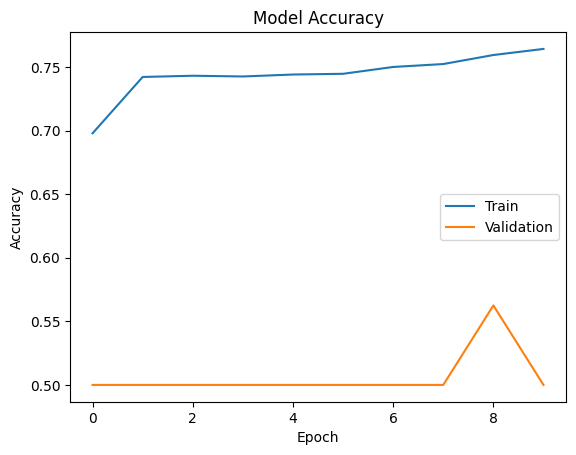

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend(["Train","Validation"])
plt.show()

In [20]:


for layer in base_model.layers[-20:]:
    layer.trainable = True

Saving chest-xray-young-boy-260nw-335470106.webp to chest-xray-young-boy-260nw-335470106 (5).webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


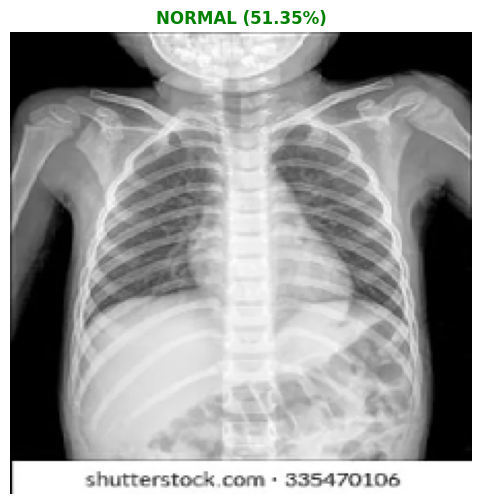

In [39]:
import numpy as np
from google.colab import files
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from IPython.display import HTML, display

model = load_model("/content/drive/MyDrive/pneumonia_resnet50_model.h5")
def predict_test_image():

    uploaded = files.upload()

    for filename in uploaded.keys():

        img = image.load_img(filename, target_size=(224,224))
        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)

        prediction = model.predict(img_array)[0][0]

        label = "PNEUMONIA" if prediction > 0.5 else "NORMAL"
        confidence = prediction if prediction > 0.5 else 1 - prediction

        plt.figure(figsize=(10, 6))
        plt.imshow(img) # Use 'img' as 'display_img' is not defined here
        plt.title(f"{label} ({confidence*100:.2f}%)", color="red" if label == "PNEUMONIA" else "green", fontweight="bold")
        plt.axis("off")
        plt.show()

        if prediction > 0.5:
            label = "PNEUMONIA"
            display(HTML("<p style='font-size: 16px; color: red;'><b>Immediate steps you should take:</b></p>"+
                         "<ol style='font-size: 14px; color: white;'>"+
                         "<li><b>See a Healthcare Professional Immediately:</b> Do not try to treat pneumonia entirely on your own. You need a doctor to listen to your lungs and potentially order an X-ray or blood tests. This is the only way to determine what kind of pneumonia you have (bacterial, viral, or fungal) so you can get the correct prescription.</li>"+
                         "<li><b>Check for Emergency 'Red Flags':</b> If you or the person you are caring for has any of the following symptoms, go to the nearest emergency room or call an ambulance immediately:"+
                         "    <ul>"+
                         "        <li>Difficulty breathing or feeling severely short of breath</li>"+
                         "        <li>Continuous, sharp chest pain</li>"+
                         "        <li>A bluish tint to the lips, face, or fingertips (indicating a lack of oxygen)</li>"+
                         "        <li>A dangerously high fever</li>"+
                         "        <li>Sudden confusion, extreme drowsiness, or a drop in mental awareness</li>"+
                         "    </ul>"+
                         "</li>"+
                         "<li><b>Follow the Prescribed Treatment Plan:</b> If a doctor has already diagnosed pneumonia and prescribed antibiotics, start taking them right away. You must finish the entire course exactly as prescribed, even if you feel 100% better halfway through. Stopping early allows the infection to survive and come back much stronger.</li>"+
                         "<li><b>Support Your Body's Recovery:</b> While your medication goes to work, you need to help your body fight the infection by:"+
                         "    <ul>"+
                         "        <li>Resting completely: Your body needs all its energy to heal.</li>"+
                         "        <li>Hydrating: Drink plenty of water, clear broths, and warm tea to help thin out the thick mucus in your lungs so you can cough it up.</li>"+
                         "        <li>Managing fever: Use over-the-counter medications like acetaminophen or ibuprofen to bring down a fever and ease the chest soreness caused by coughing.</li>"+
                         "        <li>Isolating: Stay away from others to prevent spreading the illness.</li>"+
                         "    </ul>"+
                         "</li>"+
                         "</ol>"))
        else:
            label = "NORMAL"
            display(HTML("<span style='font-size: 20px; color:pink ;'>You are the apple that every doctor fears.&#128526;&#128526;&#128375;&#128513;.(A Apple keep doctor away)</span>"))

predict_test_image()